# Tutorial 4: Unstructured Pruning on Bert

Pruning is a technique used to reduce the size and complexity of neural networks by removing unnecessary parameters (weights and connections) or structural components (neurons, filters, or layers). The goal is to create a smaller, more efficient model that maintains most of the original model's performance. The following benefits can be seen from pruning neural networks:

- **Reduce model size**: Deep neural networks often have millions of parameters, leading to large storage requirements.

- **Decrease inference time**: Fewer parameters mean fewer computations, resulting in faster predictions.

- **Improve generalization**: Removing unnecessary connections can help prevent overfitting.

- **Energy efficiency**: Smaller models require less energy to run, which is crucial for edge devices and mobile applications.

Structured pruning removes entire structures (e.g., channels, filters, or layers) from the network, while unstructured pruning removes individual weights or connections from the network, regardless of their location. In this tutorial, we'll build on top of Tutorial 3 by taking the quantized Bert model and running Mase's unstructured pruning pass. After pruning, we'll run further fine tuning iterations to retain sequence classification accuracy in the pruned model.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [2]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/Users/yashmagarwal/mase/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yashmagarwal/mase/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.c

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on Quantization-Aware Training (QAT), run the following cell to import the fine tuned checkpoint.

In [3]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_3_qat")

## Unstructured Pruning

Before running pruning, let's evaluate the model accuracy on the IMDb dataset. If you're coming from Tutorial, this would be the same as the accuracy after Quantization Aware Training (QAT). If you've just initialized the model, this will likely be a random guess (i.e. around 50%), in which case pruning wouldn't have a significant effect on the accuracy.

In [4]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /Users/yashmagarwal/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Mon Jan 26 23:00:54 2026).
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/yashmagarwal/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83944


To run the pruning pass, we pass the following pruning configuration dictionary, which defines the following parameters.

- **Sparsity**: a value between 0 and 1, expressing the proportion of elements in the model that should be pruned (i.e. set to 0).

- **Method**: several pruning methods are supported, including ``Random`` and ``L1-Norm``.

- **Scope**: defines whether to consider each weight/activation tensor individually (``local``) or all tensors in the model (``global``) when obtaining statistics for pruning (e.g. absolute value threshold for pruning)

We'll start by running random pruning with local scope, at a fixed sparsity. This may be suboptimal, but in future tutorials we'll see how to find optimal pruning and quantization configurations for a given model on a specified dataset.

In [5]:
import chop.passes as passes

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Let's evaluate the effect of pruning on accuracy. It's likely to observe drops of around 10% or more.

In [6]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=5,
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/Users/yashmagarwal/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.74272


To overcome the drop in accuracy, we'll run a few finetuning epochs. This allows the model to adapt to the new pruning mask.

In [7]:
trainer.train()

Step,Training Loss
500,0.451700
1000,0.415200
1500,0.422300
2000,0.407000
2500,0.412600
3000,0.410300
3500,0.421000
4000,0.407100
4500,0.392500
5000,0.402400


TrainOutput(global_step=15625, training_loss=0.3997108876953125, metrics={'train_runtime': 1117.1288, 'train_samples_per_second': 111.894, 'train_steps_per_second': 13.987, 'total_flos': 0.0, 'train_loss': 0.3997108876953125, 'epoch': 5.0})

Let's evaluate the model accuracy after finetuning. We should see that the accuracy is reverted back to the original level.

In [8]:
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Evaluation accuracy: 0.83244


Loading best QAT model (32-bit)...

Evaluating baseline accuracy...


/Users/yashmagarwal/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Baseline accuracy (32-bit QAT): 0.84192

Starting pruning exploration...

Testing sparsity: 0.1

[Random] Pruning with sparsity 0.1...


/Users/yashmagarwal/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

[Random] Final accuracy: 0.50452

[L1-Norm] Pruning with sparsity 0.9...


/Users/yashmagarwal/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[L1-Norm] Fine-tuning for 5 epochs...


Step,Training Loss
500,0.693200
1000,0.692500
1500,0.693000
2000,0.692700
2500,0.691900
3000,0.691800
3500,0.691900
4000,0.691400
4500,0.690900
5000,0.690800


[L1-Norm] Final accuracy: 0.54560
[Comparison] L1-Norm vs Random: +0.04108


Pruning exploration complete!



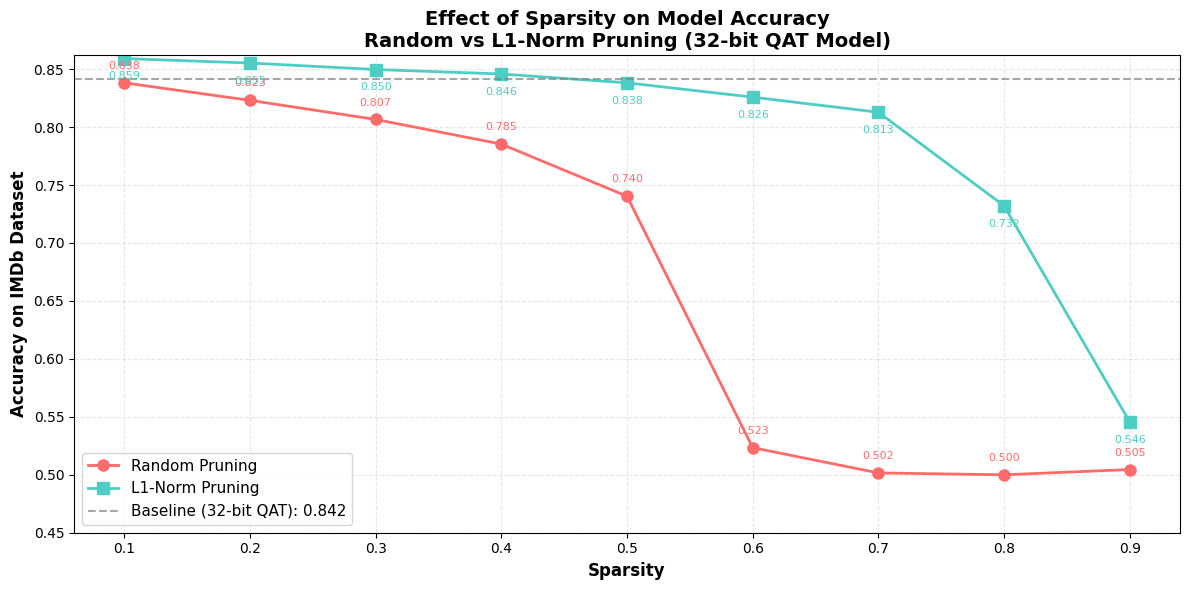


Summary Table:
Sparsity     Random       L1-Norm      Difference  
--------------------------------------------------
0.1          0.83820      0.85912      0.02092     
0.2          0.82308      0.85528      0.03220     
0.3          0.80660      0.84968      0.04308     
0.4          0.78532      0.84584      0.06052     
0.5          0.74032      0.83820      0.09788     
0.6          0.52340      0.82584      0.30244     
0.7          0.50160      0.81280      0.31120     
0.8          0.50000      0.73212      0.23212     
0.9          0.50452      0.54560      0.04108     


In [11]:
# Task 2: Pruning exploration on the best quantized model (32-bit QAT)
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from pathlib import Path

# First, save the 32-bit QAT model from Task 1 if you haven't already
# You would need to run this after completing Task 1:
# mg_qat_32bit.export(f"{Path.home()}/best_qat_32bit")

# Define the range of sparsities to test
sparsities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Storage for results
random_accuracies = []
l1norm_accuracies = []

# Load the best QAT model (32-bit) from Task 1
print("Loading best QAT model (32-bit)...")
best_qat_mg = MaseGraph.from_checkpoint(f"{Path.home()}/best_qat_32bit")

# Get the baseline accuracy
print("\nEvaluating baseline accuracy...")
trainer_baseline = get_trainer(
    model=best_qat_mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
baseline_results = trainer_baseline.evaluate()
baseline_acc = baseline_results['eval_accuracy']
print(f"Baseline accuracy (32-bit QAT): {baseline_acc:.5f}\n")

print("Starting pruning exploration...\n")

for sparsity in sparsities:
    print(f"{'='*60}")
    print(f"Testing sparsity: {sparsity}")
    print(f"{'='*60}")
    
    # ========== Random Pruning ==========
    print(f"\n[Random] Pruning with sparsity {sparsity}...")
    
    # Create a fresh copy of the model
    mg_random = deepcopy(best_qat_mg)
    
    # Create pruning configuration for Random method
    pruning_config_random = {
        "weight": {
            "sparsity": sparsity,
            "method": "random",
            "scope": "local",
        },
        "activation": {
            "sparsity": sparsity,
            "method": "random",
            "scope": "local",
        },
    }
    
    # Apply pruning
    mg_random, _ = passes.prune_transform_pass(mg_random, pass_args=pruning_config_random)
    
    # Fine-tune for 5 epochs
    trainer_random = get_trainer(
        model=mg_random.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=5,
    )
    print("[Random] Fine-tuning for 5 epochs...")
    trainer_random.train()
    
    # Evaluate final accuracy
    eval_results_random = trainer_random.evaluate()
    random_acc = eval_results_random['eval_accuracy']
    random_accuracies.append(random_acc)
    print(f"[Random] Final accuracy: {random_acc:.5f}")
    
    # ========== L1-Norm Pruning ==========
    print(f"\n[L1-Norm] Pruning with sparsity {sparsity}...")
    
    # Create a fresh copy of the model
    mg_l1norm = deepcopy(best_qat_mg)
    
    # Create pruning configuration for L1-Norm method
    pruning_config_l1norm = {
        "weight": {
            "sparsity": sparsity,
            "method": "l1-norm",
            "scope": "local",
        },
        "activation": {
            "sparsity": sparsity,
            "method": "l1-norm",
            "scope": "local",
        },
    }
    
    # Apply pruning
    mg_l1norm, _ = passes.prune_transform_pass(mg_l1norm, pass_args=pruning_config_l1norm)
    
    # Fine-tune for 5 epochs
    trainer_l1norm = get_trainer(
        model=mg_l1norm.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=5,
    )
    print("[L1-Norm] Fine-tuning for 5 epochs...")
    trainer_l1norm.train()
    
    # Evaluate final accuracy
    eval_results_l1norm = trainer_l1norm.evaluate()
    l1norm_acc = eval_results_l1norm['eval_accuracy']
    l1norm_accuracies.append(l1norm_acc)
    print(f"[L1-Norm] Final accuracy: {l1norm_acc:.5f}")
    print(f"[Comparison] L1-Norm vs Random: {l1norm_acc - random_acc:+.5f}\n")

print(f"\n{'='*60}")
print("Pruning exploration complete!")
print(f"{'='*60}\n")

# ========== Plot Results ==========
plt.figure(figsize=(12, 6))

# Plot Random and L1-Norm curves
plt.plot(sparsities, random_accuracies, marker='o', linewidth=2, 
         markersize=8, label='Random Pruning', color='#FF6B6B')
plt.plot(sparsities, l1norm_accuracies, marker='s', linewidth=2, 
         markersize=8, label='L1-Norm Pruning', color='#4ECDC4')

# Add baseline reference line
plt.axhline(y=baseline_acc, color='gray', linestyle='--', linewidth=1.5, 
            label=f'Baseline (32-bit QAT): {baseline_acc:.3f}', alpha=0.7)

# Formatting
plt.xlabel('Sparsity', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy on IMDb Dataset', fontsize=12, fontweight='bold')
plt.title('Effect of Sparsity on Model Accuracy\nRandom vs L1-Norm Pruning (32-bit QAT Model)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(sparsities)
plt.ylim([min(min(random_accuracies), min(l1norm_accuracies)) - 0.05, 
          baseline_acc + 0.02])

# Add value annotations
for i, (s, rand, l1) in enumerate(zip(sparsities, random_accuracies, l1norm_accuracies)):
    plt.annotate(f'{rand:.3f}', (s, rand), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=8, color='#FF6B6B')
    plt.annotate(f'{l1:.3f}', (s, l1), textcoords="offset points", 
                xytext=(0,-15), ha='center', fontsize=8, color='#4ECDC4')

plt.tight_layout()
plt.savefig('pruning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\nSummary Table:")
print(f"{'Sparsity':<12} {'Random':<12} {'L1-Norm':<12} {'Difference':<12}")
print(f"{'-'*50}")
for s, rand, l1 in zip(sparsities, random_accuracies, l1norm_accuracies):
    print(f"{s:<12.1f} {rand:<12.5f} {l1:<12.5f} {l1-rand:<12.5f}")